# Comparacion DF vs PINN vs Shooting (Litio)

Este notebook compara energias para los estados $(2s,3s,4s,2p,3p,3d)$ usando:
- Diferencias Finitas (DF) desde `finite-diferences/energias_litio_fortran.dat`
- PINN desde salidas guardadas en `pinn_litio_sin_datos.ipynb`
- Shooting method desde `shooting-method/energias_shooting_fortran.dat`

In [9]:
import json
import re
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

In [ ]:
base = Path('.')
df_dir = base / 'finite-diferences'
f_df = df_dir / 'energias_litio_fortran.dat'
f_shoot = base / 'shooting-method' / 'energias_shooting_fortran.dat'
f_pinn_nb = base / 'pinn_litio_sin_datos.ipynb'

for fp in [f_df, f_shoot, f_pinn_nb]:
    if not fp.exists():
        raise FileNotFoundError(f'No existe: {fp}')

print('OK archivos encontrados.')

OK archivos encontrados.


In [11]:
states = ['2s', '3s', '4s', '2p', '3p', '3d']

def load_energy_table(path, label_col=0, eev_col=-1):
    out = {}
    with open(path, 'r', encoding='utf-8') as f:
        for raw in f:
            line = raw.strip()
            if not line or line.startswith('#'):
                continue
            parts = line.split()
            if len(parts) < 2:
                continue
            try:
                out[parts[label_col]] = float(parts[eev_col])
            except ValueError:
                pass
    return out

df_e = load_energy_table(f_df, label_col=0, eev_col=-1)
shoot_e = load_energy_table(f_shoot, label_col=0, eev_col=-1)

print('DF:', df_e)
print('Shooting:', shoot_e)

DF: {'2s': -3.77154402983942, '3s': -1.61562588366597, '4s': -0.893241193155625, '2p': -3.43171712454243, '3p': -1.522179483479}
Shooting: {'2s': -9.74925391555, '3s': -2.866873966569, '4s': -1.345802408937, '2p': -3.37756015915, '3p': -1.503299361806, '3d': -1.511617979047}


In [12]:
def extract_pinn_energies_from_notebook(nb_path):
    with open(nb_path, 'r', encoding='utf-8') as f:
        nb = json.load(f)

    pinn = {}
    pat = re.compile(r'Entrenando estado\s+([0-9][spd])\s+\.\.\.')
    pat_e = re.compile(r'->\s*E_PINN\s*=\s*([-+]?\d+(?:\.\d+)?)\s*eV')

    current_state = None

    for cell in nb.get('cells', []):
        for out in cell.get('outputs', []):
            texts = []
            if isinstance(out.get('text'), list):
                texts.extend(out['text'])
            elif isinstance(out.get('text'), str):
                texts.append(out['text'])

            data_txt = out.get('data', {}).get('text/plain')
            if isinstance(data_txt, list):
                texts.extend(data_txt)
            elif isinstance(data_txt, str):
                texts.append(data_txt)

            for t in texts:
                for line in str(t).splitlines():
                    m_state = pat.search(line)
                    if m_state:
                        current_state = m_state.group(1)

                    m_e = pat_e.search(line)
                    if m_e and current_state is not None:
                        pinn[current_state] = float(m_e.group(1))

    return pinn

pinn_e = extract_pinn_energies_from_notebook(f_pinn_nb)
print('PINN extraido del notebook:', pinn_e)

PINN extraido del notebook: {'2s': -9.2987, '3s': -1.5324, '4s': -0.0, '2p': -3.3396, '3p': -0.0}


In [13]:
def aligned_vector(d, keys):
    return np.array([d.get(k, np.nan) for k in keys], dtype=float)

E_df = aligned_vector(df_e, states)
E_pinn = aligned_vector(pinn_e, states)
E_shoot = aligned_vector(shoot_e, states)

print('Estado   DF(eV)      PINN(eV)    Shooting(eV)')
for i, st in enumerate(states):
    print(f"{st:>3}   {E_df[i]:>10.5f}   {E_pinn[i]:>10.5f}   {E_shoot[i]:>12.5f}")

Estado   DF(eV)      PINN(eV)    Shooting(eV)
 2s     -3.77154     -9.29870       -9.74925
 3s     -1.61563     -1.53240       -2.86687
 4s     -0.89324     -0.00000       -1.34580
 2p     -3.43172     -3.33960       -3.37756
 3p     -1.52218     -0.00000       -1.50330
 3d          nan          nan       -1.51162


In [14]:
# Errores relativos usando DF como referencia
eps = 1e-14
err_pinn = np.abs(E_pinn - E_df) / (np.abs(E_df) + eps)
err_shoot = np.abs(E_shoot - E_df) / (np.abs(E_df) + eps)

print('Estado   Err(PINN vs DF)   Err(Shooting vs DF)')
for i, st in enumerate(states):
    print(f"{st:>3}      {err_pinn[i]:>10.4e}         {err_shoot[i]:>10.4e}")

Estado   Err(PINN vs DF)   Err(Shooting vs DF)
 2s      1.4655e+00         1.5850e+00
 3s      5.1513e-02         7.7447e-01
 4s      1.0000e+00         5.0665e-01
 2p      2.6843e-02         1.5781e-02
 3p      1.0000e+00         1.2403e-02
 3d             nan                nan


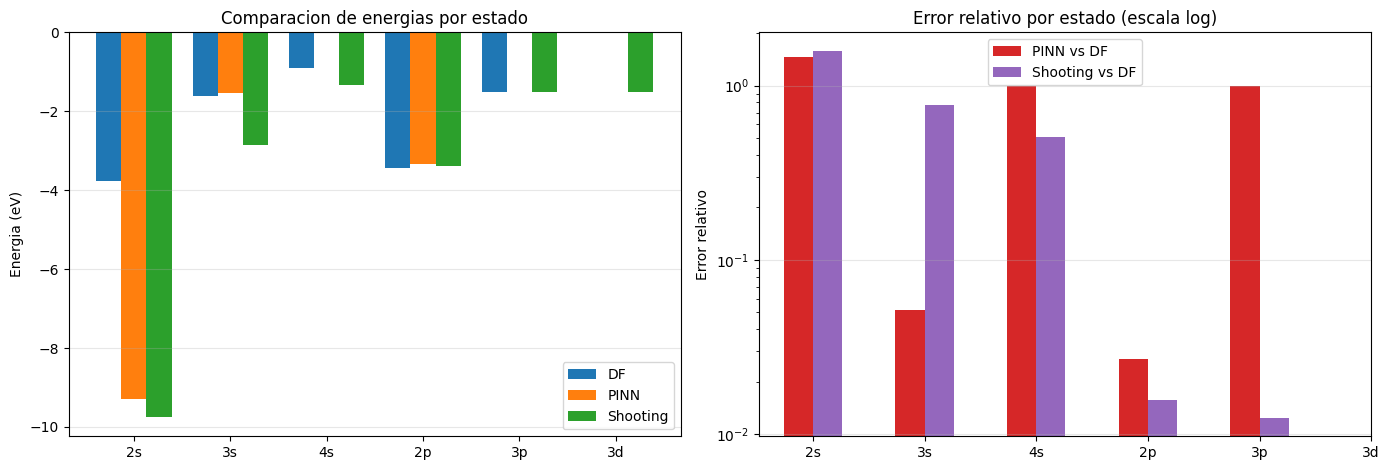

In [15]:
x = np.arange(len(states))
w = 0.26

fig, ax = plt.subplots(1, 2, figsize=(14, 4.8))

ax[0].bar(x - w, E_df, width=w, label='DF', color='tab:blue')
ax[0].bar(x, E_pinn, width=w, label='PINN', color='tab:orange')
ax[0].bar(x + w, E_shoot, width=w, label='Shooting', color='tab:green')
ax[0].set_xticks(x)
ax[0].set_xticklabels(states)
ax[0].set_ylabel('Energia (eV)')
ax[0].set_title('Comparacion de energias por estado')
ax[0].grid(True, axis='y', alpha=0.3)
ax[0].legend()

ax[1].bar(x - w/2, err_pinn, width=w, label='PINN vs DF', color='tab:red')
ax[1].bar(x + w/2, err_shoot, width=w, label='Shooting vs DF', color='tab:purple')
ax[1].set_xticks(x)
ax[1].set_xticklabels(states)
ax[1].set_yscale('log')
ax[1].set_ylabel('Error relativo')
ax[1].set_title('Error relativo por estado (escala log)')
ax[1].grid(True, axis='y', alpha=0.3)
ax[1].legend()

plt.tight_layout()
plt.show()

## Comparacion radial con la grafica de referencia (desde DAT)

Esta seccion replica la estructura de la grafica de referencia de `graficas_litio_desde_dat.ipynb`:
- Panel A: estados s (2s, 3s, 4s)
- Panel B: estados p (2p, 3p)

Sobre esa misma base de DF, se superponen las curvas de Shooting y, si existen archivos, las de PINN.

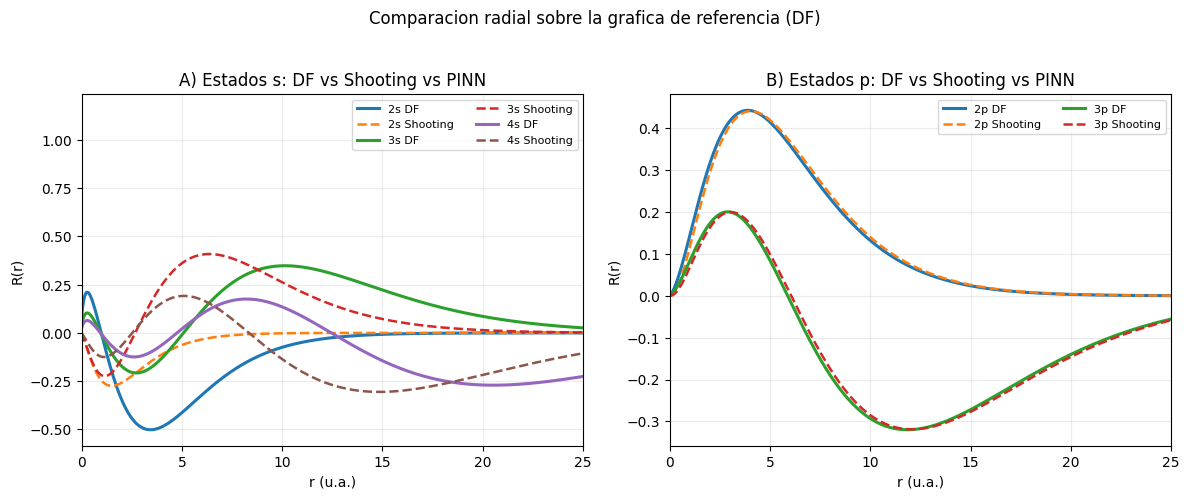

Referencia DF usada: funciones_radiales_litio.dat
Nota: para incluir PINN por estado, agrega archivos funcion_radial_pinn_<estado>.dat


In [ ]:
base = Path('.')
df_dir = base / 'finite-diferences'
f_df = df_dir / 'energias_litio_fortran.dat'
f_shoot = base / 'shooting-method' / 'energias_shooting_fortran.dat'
f_pinn_nb = base / 'pinn_litio_sin_datos.ipynb'

for fp in [f_df, f_shoot, f_pinn_nb]:
    if not fp.exists():
        raise FileNotFoundError(f'No existe: {fp}')

print('OK archivos encontrados.')